In [8]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Task 1: Load Dataset 

In [10]:
data = pd.read_csv('SCMS Delivery History Dataset.csv')

In [24]:
# Display first 10 rows 
print('First 10 rows of datasets')
data.head(10)

First 10 rows of datasets


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN
5,23,112-NG-T01,Pre-PQ Process,SCMS-87,ASN-57,Nigeria,PMO - US,Direct Drop,EXW,Air,...,240,416,2225.60,5.35,0.02,"Aurobindo Unit III, India",Yes,504,5920.42,NaN
6,44,110-ZM-T01,Pre-PQ Process,SCMS-139,ASN-130,Zambia,PMO - US,Direct Drop,DDU,Air,...,90,135,4374.00,32.40,0.36,MSD South Granville Australia,Yes,328,Freight Included in Commodity Cost,NaN
7,45,109-TZ-T01,Pre-PQ Process,SCMS-140,ASN-94,Tanzania,PMO - US,Direct Drop,EXW,Air,...,60,16667,60834.55,3.65,0.06,"Aurobindo Unit III, India",Yes,1478,6212.41,NaN
8,46,112-NG-T01,Pre-PQ Process,SCMS-156,ASN-93,Nigeria,PMO - US,Direct Drop,EXW,Air,...,60,273,532.35,1.95,0.03,"Aurobindo Unit III, India",No,See ASN-93 (ID#:1281),See ASN-93 (ID#:1281),NaN
9,47,110-ZM-T01,Pre-PQ Process,SCMS-165,ASN-199,Zambia,PMO - US,Direct Drop,CIP,Air,...,120,2800,115080.00,41.10,0.34,ABBVIE (Abbott) St. P'burg USA,Yes,643,Freight Included in Commodity Cost,NaN


In [19]:
#Check shape and column names 
print('Shape of data .... ')
data.shape

Shape of data .... 


(10324, 33)

In [22]:
print('dataset columns names....')
data.columns

dataset columns names....


Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

# Task 2: Data Cleaning

In [ ]:
# 1. Convert all date columns into proper datetime format 

In [28]:
date_columns = [
    "PQ First Sent to Client Date",
    "PO Sent to Vendor Date",
    "Scheduled Delivery Date",
    "Delivered to Client Date",
    "Delivery Recorded Date"
]
for col in date_columns:
    data[col] = pd.to_datetime(data[col], errors='coerce')

print("Date columns converted successfully.\n")

Date columns converted successfully.



In [29]:
# 2. Identify Missing Values

In [32]:
data.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [59]:
# Convert numeric columns first
numeric_columns = [
    "Freight Cost (USD)",
    "Weight (Kilograms)",
    "Unit Price",
    "Line Item Insurance (USD)"
]

# Convert columns to numeric
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Fill missing values in Insurance column using median
data["Line Item Insurance (USD)"] = data["Line Item Insurance (USD)"].fillna(
    data["Line Item Insurance (USD)"].median()
)

In [73]:
# Fill missing values in categorical columns using Mode
categorical_columns = [
    "Shipment Mode",
    "Vendor INCO Term",
    "Dosage",
    "Dosage Form"
]

for col in categorical_columns:
    if col in data.columns and data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

print("\nMissing values handled successfully.")



Missing values handled successfully.


In [70]:
# 4. Convert Numeric Columns

data["Freight Cost (USD)"] = pd.to_numeric(data["Freight Cost (USD)"], errors="coerce")
data["Weight (Kilograms)"] = pd.to_numeric(data["Weight (Kilograms)"], errors="coerce")
data["Unit Price"] = pd.to_numeric(data["Unit Price"], errors="coerce")

print("\nNumeric columns converted successfully.")


Numeric columns converted successfully.


In [74]:
data.isnull().sum()

ID                              0
Project Code                    0
PQ #                            0
PO / SO #                       0
ASN/DN #                        0
Country                         0
Managed By                      0
Fulfill Via                     0
Vendor INCO Term                0
Shipment Mode                   0
PQ First Sent to Client Date    0
PO Sent to Vendor Date          0
Scheduled Delivery Date         0
Delivered to Client Date        0
Delivery Recorded Date          0
Product Group                   0
Sub Classification              0
Vendor                          0
Item Description                0
Molecule/Test Type              0
Brand                           0
Dosage                          0
Dosage Form                     0
Unit of Measure (Per Pack)      0
Line Item Quantity              0
Line Item Value                 0
Pack Price                      0
Unit Price                      0
Manufacturing Site              0
First Line Des

# Exploratory Data Analysis (EDA)

Shipment Analysis

In [81]:
# Most Common Shipment Mode
print("\nMost Common Shipment Mode:")
print(data["Shipment Mode"].value_counts())


Most Common Shipment Mode:
Shipment Mode
Air            6473
Truck          2830
Air Charter     650
Ocean           371
Name: count, dtype: int64


Total shipments per country

In [87]:
print('\nTotal Shipment Per Country:')
print(data["Country"].value_counts())


Total Shipment Per Country:
Country
South Africa          1406
Nigeria               1194
Côte d'Ivoire         1083
Uganda                 779
Vietnam                688
Zambia                 683
Haiti                  655
Mozambique             631
Zimbabwe               538
Tanzania               519
Rwanda                 430
Congo, DRC             333
Guyana                 237
Ethiopia               216
South Sudan            164
Kenya                  111
Burundi                 98
Namibia                 95
Cameroon                75
Botswana                70
Ghana                   58
Dominican Republic      52
Sudan                   46
Swaziland               35
Mali                    17
Guatemala               15
Pakistan                15
Malawi                  14
Benin                   13
Lebanon                  8
Libya                    8
Angola                   7
Liberia                  6
Lesotho                  4
Sierra Leone             4
Afghanistan       

Delivery Performance 

In [92]:
# Calculate delivery delay (Scheduled vs Delivered Date)

data["Delivery Delay (Days)"] = (
    data["Delivered to Client Date"] - data["Scheduled Delivery Date"]
).dt.days

print("\nDelivery Delay (First 10 Records):")

print(data[
    [
        "Scheduled Delivery Date",
        "Delivered to Client Date",
        "Delivery Delay (Days)"
    ]
].head(10))


Delivery Delay (First 10 Records):
  Scheduled Delivery Date Delivered to Client Date  Delivery Delay (Days)
0              2006-06-02               2006-06-02                      0
1              2006-11-14               2006-11-14                      0
2              2006-08-27               2006-08-27                      0
3              2006-09-01               2006-09-01                      0
4              2006-08-11               2006-08-11                      0
5              2006-09-28               2006-09-28                      0
6              2007-01-08               2007-01-08                      0
7              2006-11-24               2006-11-24                      0
8              2006-12-07               2006-12-07                      0
9              2007-01-30               2007-01-30                      0


In [94]:
# Average Delivery Time
average_delay = data["Delivery Delay (Days)"].mean()

print("\nAverage Delivery Delay:")
print(round(average_delay, 2), "Days")

# Delayed Shipments
delayed_shipments = data[data["Delivery Delay (Days)"] > 0]

print("\nNumber of Delayed Shipments:")
print(len(delayed_shipments))


Average Delivery Delay:
-6.02 Days

Number of Delayed Shipments:
1186


Cost Analysis

In [96]:
# Total Freight Cost
total_freight = data["Freight Cost (USD)"].sum()


93036045.94000001


In [100]:
#Average Lime Item Value
average_line_item = data["Line Item Value"].mean()


157650.56734695853


In [102]:
#Total Insurance Cost
total_insurance = data["Line Item Insurance (USD)"].sum()

print(f"\nTotal Freight Cost: ${total_freight:,.2f}")
print(f"Average Line Item Value: ${average_line_item:,.2f}")
print(f"Total Insurance Cost: ${total_insurance:,.2f}")


Total Freight Cost: $93,036,045.94
Average Line Item Value: $157,650.57
Total Insurance Cost: $2,423,561.09


# Task 4: Group-Based Analysis

Country vs total shipments 

In [124]:
country_shipments = data.groupby("Country").size().reset_index(name="Total Shipment")
print(country_shipments)

               Country  Total Shipment
0          Afghanistan               3
1               Angola               7
2               Belize               1
3                Benin              13
4             Botswana              70
5         Burkina Faso               2
6              Burundi              98
7             Cameroon              75
8           Congo, DRC             333
9        Côte d'Ivoire            1083
10  Dominican Republic              52
11            Ethiopia             216
12               Ghana              58
13           Guatemala              15
14              Guinea               1
15              Guyana             237
16               Haiti             655
17          Kazakhstan               2
18               Kenya             111
19          Kyrgyzstan               2
20             Lebanon               8
21             Lesotho               4
22             Liberia               6
23               Libya               8
24              Malawi   

In [125]:
# Vendor vs total cost 

In [126]:
vendor_cost = data.groupby("Vendor")["Freight Cost (USD)"].sum().reset_index(name = "Total Freight Cost")
print(vendor_cost)

                                               Vendor  Total Freight Cost
0                   ABBOTT LABORATORIES (PUERTO RICO)             314.000
1                               ABBOTT LOGISTICS B.V.            5869.655
2     ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)         2187900.900
3   ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTE...           18275.625
4                                    ACCESS BIO, INC.            5642.360
..                                                ...                 ...
68                        THE MEDICAL EXPORT GROUP BV           37744.270
69     TURE PHARMACEUTICALS & MEDICAL SUPPLIES P.L.C.           17608.965
70                               Trinity Biotech, Plc         2831828.835
71                                            WAGENIA           11739.310
72                                 ZEPHYR BIOMEDICALS           12753.830

[73 rows x 2 columns]


In [127]:
# Product Group vs total value

In [128]:
product_value = data.groupby("Product Group")["Line Item Value"].sum().reset_index(name="Total Value")

print(product_value)

  Product Group   Total Value
0           ACT  6.643809e+05
1          ANTM  2.741766e+05
2           ARV  1.413220e+09
3          HRDT  2.133448e+08
4          MRDT  8.106510e+04


In [129]:
# Shipment Mode vs average delay 

In [130]:
shipment_delay = data.groupby("Shipment Mode")["Delivery Delay (Days)"].mean().reset_index(name="Average Delay")

print(shipment_delay)

  Shipment Mode  Average Delay
0           Air      -3.694114
1   Air Charter     -19.036923
2         Ocean       5.870620
3         Truck      -9.921908


# Task 5: Visualizations

1. Bar chart → Country vs Shipments 

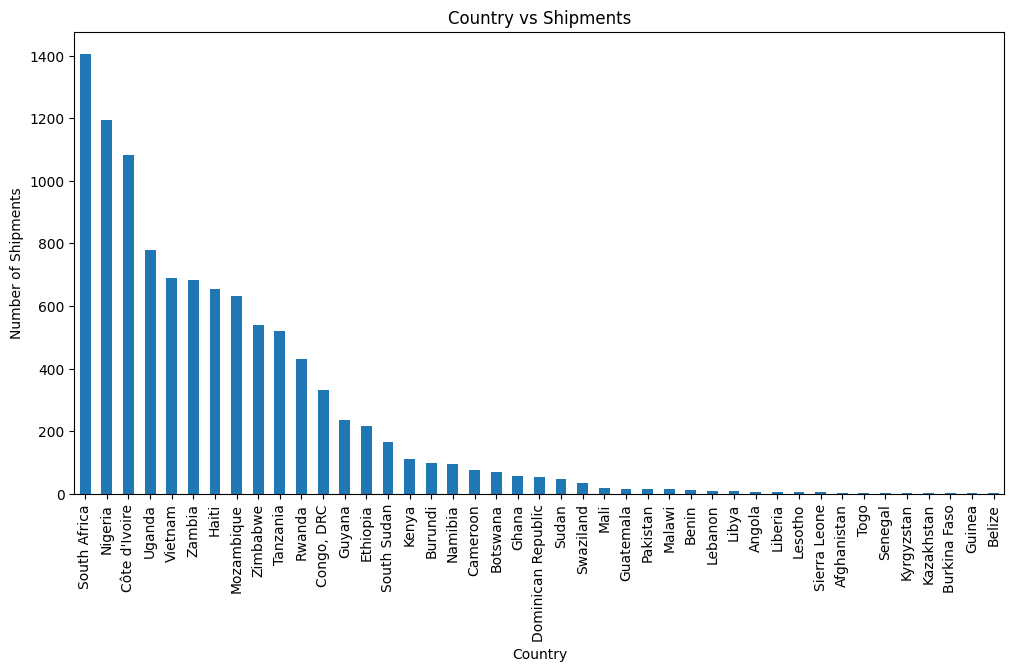

In [142]:
country_shipments = data["Country"].value_counts()

plt.figure(figsize=(12,6))
country_shipments.plot(kind="bar")

plt.title("Country vs Shipments")
plt.xlabel("Country")
plt.ylabel("Number of Shipments")
plt.xticks(ticks=range(len(country_shipments)), labels=country_shipments.index, rotation=90)

plt.show()

2. Pie chart → Shipment Mode distribution 

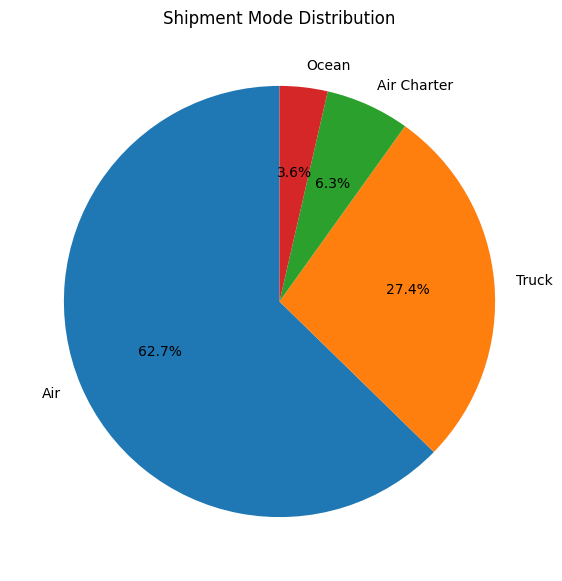

In [145]:
# Shipment Mode Distribution
shipment_mode = data["Shipment Mode"].value_counts()

# Create Pie Chart
plt.figure(figsize=(7,7))
plt.pie(
    shipment_mode,
    labels=shipment_mode.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Shipment Mode Distribution")

plt.show()

3. Line chart → Delivery trend over time 

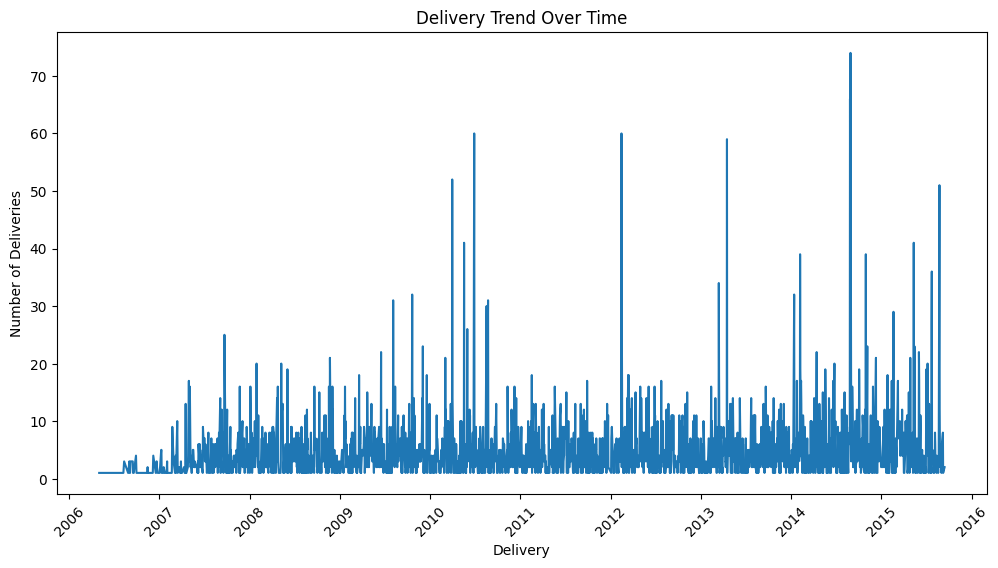

In [147]:
# Count Deliveries by Date
delivery_trend = data.groupby("Delivered to Client Date").size()

# Create Line Chart
plt.figure(figsize=(12,6))
plt.plot(delivery_trend.index, delivery_trend.values)

plt.title("Delivery Trend Over Time")
plt.xlabel("Delivery")
plt.ylabel("Number of Deliveries")

plt.xticks(rotation=45)

plt.show()